In [3]:
from mossbauer_analysis.ironanalytics_load import read_ironanalytics_data, print_ironanalytics_metadata 
import mossbauer_analysis.utils as u
from mossbauer_analysis.ironanalytics_analyze import fit_and_calibrate
from mossbauer_analysis.mossbauer_theory import CobaltRhodium, CobaltFe, KFeCy, alphaFe, Mossbauer, _lorentzian_s, mms_to_ev, ev_to_mms
from mossbauer_analysis.mossbauer_fit_model import optimize_linewidth_s, optimize_thickness, fit_gamma_and_thickness

import os
import numpy as np
import matplotlib.pyplot as plt

In [4]:

directory = "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/"
data_alphaFe = read_ironanalytics_data(directory, "A00156", offset = -3, plot = False)
data_dep10 = read_ironanalytics_data(directory, "A00152", offset = -3, plot = False)
data_dep102mms = read_ironanalytics_data(directory, "A00153", offset = -3, plot = False)
data_dep9 = read_ironanalytics_data(directory, "A00142", offset = -3, plot = False)
data_alphaFeFesource = read_ironanalytics_data(directory, "A00137", offset = -3, plot = False)
data_dep8 = read_ironanalytics_data(directory, "A00141", offset = -3, plot = False)

#data_alphaFe = read_ironanalytics_data(directory, "A00164", offset = -3, plot = False)


gamma:	 6.378 neV, 
A:	 1.266, 
B:	 0.635, 
x0:	 -0.159 mm/s, 
s:	 1.267


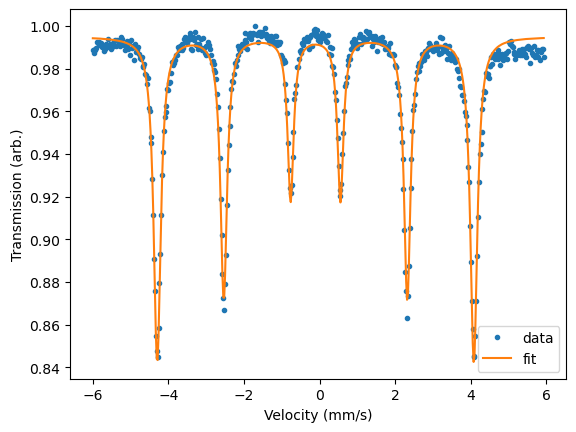

In [5]:
from scipy.optimize import least_squares

from mossbauer_analysis.mossbauer_fit_model import S_fast


directory = "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/"
data_alphaFe = read_ironanalytics_data(directory, "A00156", offset = -3, plot = False)
#data_alphaFe = read_ironanalytics_data(directory, "A00164", offset = -3, plot = False)


#SOURCE
source = CobaltRhodium ()
source.Eres = [-0.11] #from pipcorn
source.Gamma_ev = 6.55e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.0212
absorber.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorber.update_params()

#DATA
xdata = data_alphaFe.velocity_list
ydata = data_alphaFe.data_left/max(data_alphaFe.data_left)



def residuals(theta, xdata, ydata, absorber, source):
    gamma, A, B, x0, s = theta

    # update physics
    source.Gamma_ev = gamma
    source.update_params()

    v_eff = s * (xdata - x0)
    y_model = S_fast(v_eff, absorber, source)

    return A*y_model + B - ydata


theta0 = [
    7e-9,        # gamma
    .1,         # A
    0.5,         # B
    -0.15,         # x0
    1.3          # s
]

bounds = (
    [6e-9, 0.1, -1.0, -1.0, 0.8],   # lower
    [8e-9, 2.0,  1.0,  1.0, 1.4]    # upper
)

res = least_squares(
    residuals,
    theta0,
    bounds=bounds,
    args=(xdata, ydata, absorber, source),
    method='trf'
)

gamma_fit, A_fit, B_fit, x0_fit, s_fit = res.x
print(
    f"gamma:\t {gamma_fit*1e9:.3f} neV, \n"
    f"A:\t {A_fit:.3f}, \n"
    f"B:\t {B_fit:.3f}, \n"
    f"x0:\t {x0_fit:.3f} mm/s, \n"
    f"s:\t {s_fit:.3f}"
)


plt.plot(xdata, ydata, ".", label="data")
# To plot the model, we need to update the absorber and source with the fitted parameters
source.Gamma_ev = gamma_fit
source.update_params()
v_eff = s_fit * (xdata - x0_fit)
y_fit = A_fit * S_fast(v_eff, absorber, source) + B_fit
plt.plot(xdata, y_fit, "-", label="fit")
plt.xlabel("Velocity (mm/s)")
plt.ylabel("Transmission (arb.)")
plt.legend()



t:	 0.71 mum, 
A:	 0.415, 
B:	 0.596, 
x0:	 -0.160 mm/s, 
s:	 1.249


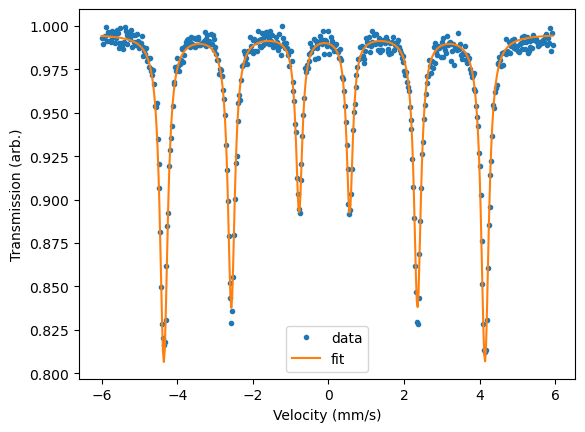

In [4]:
from scipy.optimize import least_squares

from mossbauer_analysis.mossbauer_fit_model import S_fast

directory = "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/"

data_dep10 = read_ironanalytics_data(directory, "A00152", offset = -3, plot = False)
data_dep9 = read_ironanalytics_data(directory, "A00142", offset = -3, plot = False)
data_dep8 = read_ironanalytics_data(directory, "A00141", offset = -3, plot = False)

data = data_dep10

#SOURCE
source = CobaltRhodium ()
source.Eres = [-0.11] #from pipcorn
source.Gamma_ev = gamma_fit
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 0.3e-6
absorber.abundance = 0.96
absorber.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorber.update_params()

#DATA
xdata = data.velocity_list
ydata = data.data_left/max(data.data_left)


def residuals(theta, xdata, ydata, absorber, source):
    t, A, B, x0, s = theta

    absorber.thickness_m = t
    absorber.update_params()

    v_eff = s * (xdata - x0)
    y_model = S_fast(v_eff, absorber, source)

    return A*y_model + B - ydata


theta0 = [
    500e-9,      # thickness
    1.0,         # A
    0.5,         # B
    -0.15,         # x0
    1.3          # s
]

bounds = (
    [  50e-9,  0.1, -1.0, -1.0, 0.8],   # lower
    [ 900e-9, 2.0,  1.0,  1.0, 1.4]    # upper
)

res = least_squares(
    residuals,
    theta0,
    bounds=bounds,
    args=(xdata, ydata, absorber, source),
    method='trf'
)

t_fit, A_fit, B_fit, x0_fit, s_fit = res.x
print(
    f"t:\t {t_fit*1e6:.2f} mum, \n"
    f"A:\t {A_fit:.3f}, \n"
    f"B:\t {B_fit:.3f}, \n"
    f"x0:\t {x0_fit:.3f} mm/s, \n"
    f"s:\t {s_fit:.3f}"
)


plt.figure()


plt.plot(xdata, ydata, ".", label="data")
# To plot the model, we need to update the absorber and source with the fitted parameters
absorber.thickness_m = t_fit
absorber.update_params()
v_eff = s_fit * (xdata - x0_fit)
y_fit = A_fit * S_fast(v_eff, absorber, source) + B_fit
plt.plot(xdata, y_fit, "-", label="fit")
plt.xlabel("Velocity (mm/s)")
plt.ylabel("Transmission (arb.)")
plt.legend()


gamma:	 6.614 neV, 
A:	 1.097, 
B:	 0.690, 
x0:	 -0.004 mm/s, 
s:	 1.372


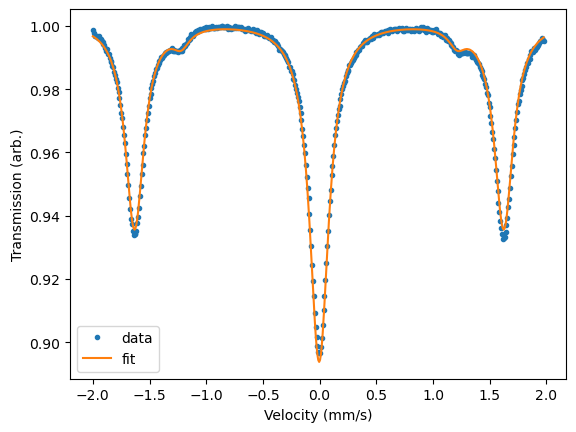

In [5]:
from scipy.optimize import least_squares

from mossbauer_analysis.mossbauer_fit_model import S_fast


directory = "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/"

data_alphaFe  = read_ironanalytics_data(directory, "A00137", offset = -3, plot = False)



#SOURCE
source = CobaltFe ()
source.Gamma_ev = 6.55e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.0212
absorber.update_params()

#DATA
xdata = data_alphaFe.velocity_list
ydata = data_alphaFe.data_folded/max(data_alphaFe.data_folded)


def residuals(theta, xdata, ydata, absorber, source):
    gamma, A, B, x0, s = theta

    # update physics
    source.Gamma_ev = gamma
    source.update_params()

    v_eff = s * (xdata - x0)
    y_model = S_fast(v_eff, absorber, source)

    return A*y_model + B - ydata


theta0 = [
    7e-9,        # gamma
    .1,         # A
    0.5,         # B
    -0.15,         # x0
    1.3          # s
]

bounds = (
    [5e-9, 0.1, -1.0, -1.0, 0.8],   # lower
    [9e-9, 2.0,  1.0,  1.0, 1.4]    # upper
)

res = least_squares(
    residuals,
    theta0,
    bounds=bounds,
    args=(xdata, ydata, absorber, source),
    method='trf'
)

gamma_fit, A_fit, B_fit, x0_fit, s_fit = res.x
print(
    f"gamma:\t {gamma_fit*1e9:.3f} neV, \n"
    f"A:\t {A_fit:.3f}, \n"
    f"B:\t {B_fit:.3f}, \n"
    f"x0:\t {x0_fit:.3f} mm/s, \n"
    f"s:\t {s_fit:.3f}"
)


plt.plot(xdata, ydata, ".", label="data")
# To plot the model, we need to update the absorber and source with the fitted parameters
source.Gamma_ev = gamma_fit
source.update_params()
v_eff = s_fit * (xdata - x0_fit)
y_fit = A_fit * S_fast(v_eff, absorber, source) + B_fit
plt.plot(xdata, y_fit, "-", label="fit")
plt.xlabel("Velocity (mm/s)")
plt.ylabel("Transmission (arb.)")
plt.legend()



t:	 0.31 mum, 
A:	 0.283, 
B:	 0.721, 
x0:	 -0.003 mm/s, 
s:	 1.382


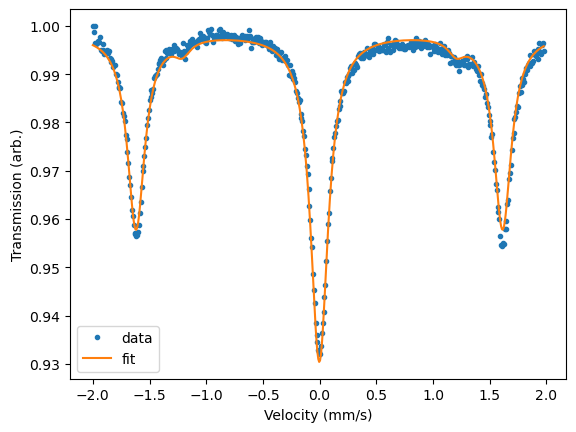

In [6]:

directory = "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/"

data_dep9 = read_ironanalytics_data(directory, "A00142", offset = -3, plot = False)
data_dep8 = read_ironanalytics_data(directory, "A00141", offset = -3, plot = False)

data = data_dep8

#SOURCE
source = CobaltFe ()
source.Eres =[-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
source.Gamma_ev = gamma_fit
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 0.3e-6
absorber.abundance = 0.96
absorber.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorber.update_params()

#DATA
xdata = data.velocity_list
ydata = data.data_folded/max(data.data_folded)


def residuals(theta, xdata, ydata, absorber, source):
    t, A, B, x0, s = theta

    absorber.thickness_m = t
    absorber.update_params()

    v_eff = s * (xdata - x0)
    y_model = S_fast(v_eff, absorber, source)

    return A*y_model + B - ydata


theta0 = [
    500e-9,      # thickness
    1.0,         # A
    0.5,         # B
    -0.15,         # x0
    1.3          # s
]

bounds = (
    [  50e-9,  0.1, -1.0, -1.0, 0.8],   # lower
    [ 900e-9, 2.0,  1.0,  1.0, 1.4]    # upper
)

res = least_squares(
    residuals,
    theta0,
    bounds=bounds,
    args=(xdata, ydata, absorber, source),
    method='trf'
)

t_fit, A_fit, B_fit, x0_fit, s_fit = res.x
print(
    f"t:\t {t_fit*1e6:.2f} mum, \n"
    f"A:\t {A_fit:.3f}, \n"
    f"B:\t {B_fit:.3f}, \n"
    f"x0:\t {x0_fit:.3f} mm/s, \n"
    f"s:\t {s_fit:.3f}"
)


plt.figure()


plt.plot(xdata, ydata, ".", label="data")
# To plot the model, we need to update the absorber and source with the fitted parameters
absorber.thickness_m = t_fit
absorber.update_params()
v_eff = s_fit * (xdata - x0_fit)
y_fit = A_fit * S_fast(v_eff, absorber, source) + B_fit
plt.plot(xdata, y_fit, "-", label="fit")
plt.xlabel("Velocity (mm/s)")
plt.ylabel("Transmission (arb.)")
plt.legend()


t:	 0.26 mum, 
A:	 0.248, 
B:	 0.753, 
x0:	 -0.004 mm/s, 
s:	 1.385


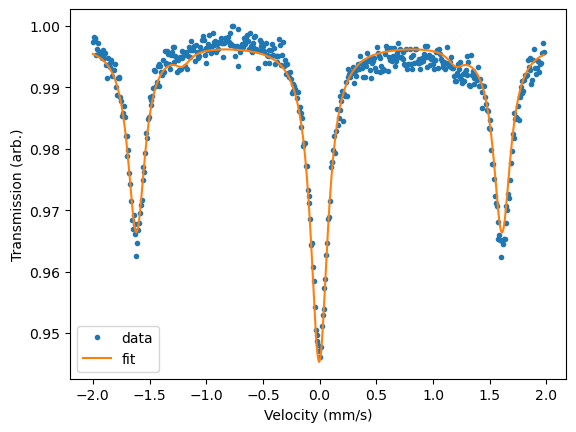

In [7]:

directory = "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/"

data_dep9 = read_ironanalytics_data(directory, "A00142", offset = -3, plot = False)
data_dep8 = read_ironanalytics_data(directory, "A00141", offset = -3, plot = False)

data = data_dep9

#SOURCE
source = CobaltFe ()
source.Eres =[-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
source.Gamma_ev = gamma_fit
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 0.3e-6
absorber.abundance = 0.96
absorber.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorber.update_params()

#DATA
xdata = data.velocity_list
ydata = data.data_folded/max(data.data_folded)


def residuals(theta, xdata, ydata, absorber, source):
    t, A, B, x0, s = theta

    absorber.thickness_m = t
    absorber.update_params()

    v_eff = s * (xdata - x0)
    y_model = S_fast(v_eff, absorber, source)

    return A*y_model + B - ydata


theta0 = [
    500e-9,      # thickness
    1.0,         # A
    0.5,         # B
    -0.15,         # x0
    1.3          # s
]

bounds = (
    [  50e-9,  0.1, -1.0, -1.0, 0.8],   # lower
    [ 900e-9, 2.0,  1.0,  1.0, 1.4]    # upper
)

res = least_squares(
    residuals,
    theta0,
    bounds=bounds,
    args=(xdata, ydata, absorber, source),
    method='trf'
)

t_fit, A_fit, B_fit, x0_fit, s_fit = res.x
print(
    f"t:\t {t_fit*1e6:.2f} mum, \n"
    f"A:\t {A_fit:.3f}, \n"
    f"B:\t {B_fit:.3f}, \n"
    f"x0:\t {x0_fit:.3f} mm/s, \n"
    f"s:\t {s_fit:.3f}"
)


plt.figure()


plt.plot(xdata, ydata, ".", label="data")
# To plot the model, we need to update the absorber and source with the fitted parameters
source.Gamma_ev = gamma_fit
source.update_params()
absorber.thickness_m = t_fit
absorber.update_params()
v_eff = s_fit * (xdata - x0_fit)
y_fit = A_fit * S_fast(v_eff, absorber, source) + B_fit
plt.plot(xdata, y_fit, "-", label="fit")
plt.xlabel("Velocity (mm/s)")
plt.ylabel("Transmission (arb.)")
plt.legend()


t:	 24.74 mum, 
A:	 1.107, 
B:	 0.684, 
x0:	 -0.004 mm/s, 
s:	 1.372


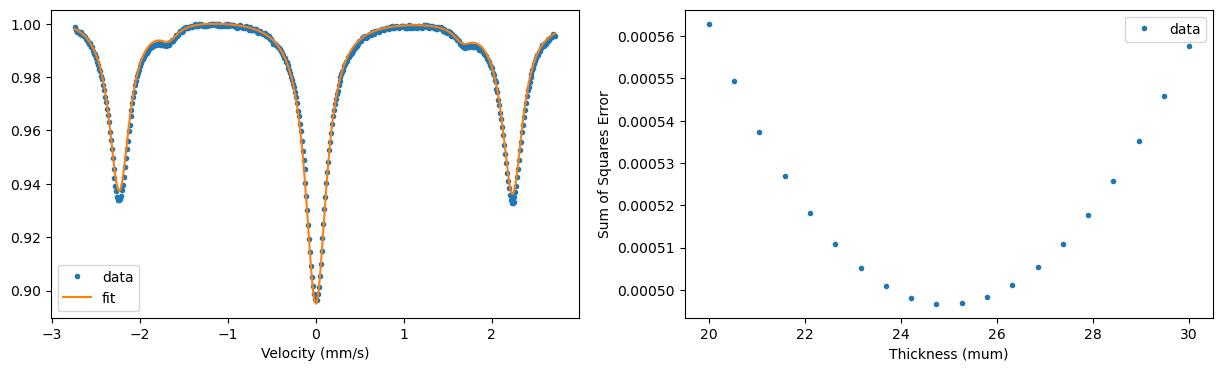

In [10]:
data_alphaFe  = read_ironanalytics_data(directory, "A00137", offset = -3, plot = False)
data_dep10 = read_ironanalytics_data(directory, "A00152", offset = -3, plot = False)
data_dep9 = read_ironanalytics_data(directory, "A00142", offset = -3, plot = False)
data_dep8 = read_ironanalytics_data(directory, "A00141", offset = -3, plot = False)

data = data_alphaFe


#SOURCE
source = CobaltFe ()
source.Gamma_ev = 6.9e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.0212
absorber.update_params()

#DATA
xdata = data_alphaFe.velocity_list
ydata = data_alphaFe.data_folded/max(data_alphaFe.data_folded)

t_grid = np.linspace(20e-6, 30e-6, 20)
x_model = np.linspace(-30, 30, 1000)

params, sse, x_calibrated, y_model, y_fit = optimize_thickness(xdata, ydata, t_grid,  absorber, source,x_model, fast=True)



print(
    f"t:\t {params['t']*1e6:.2f} mum, \n"
    f"A:\t {params['A']:.3f}, \n"
    f"B:\t {params['B']:.3f}, \n"
    f"x0:\t {params['x0']:.3f} mm/s, \n"
    f"s:\t {params['s']:.3f}"
)


fig, ax = plt.subplots(1,2, figsize=(15,4))
ax[0].plot(x_calibrated, ydata, ".", label="data")
ax[0].plot(x_calibrated, y_fit, "-", label="fit")
ax[0].set_xlabel("Velocity (mm/s)")   
ax[0].legend()

ax[1].plot(t_grid*1e6, sse, ".", label="data")
ax[1].set_xlabel("Thickness (mum)")
ax[1].set_ylabel("Sum of Squares Error")
ax[1].legend()

t:	 0.19 mum, 
A:	 0.314, 
B:	 0.688, 
x0:	 -0.004 mm/s, 
s:	 1.385


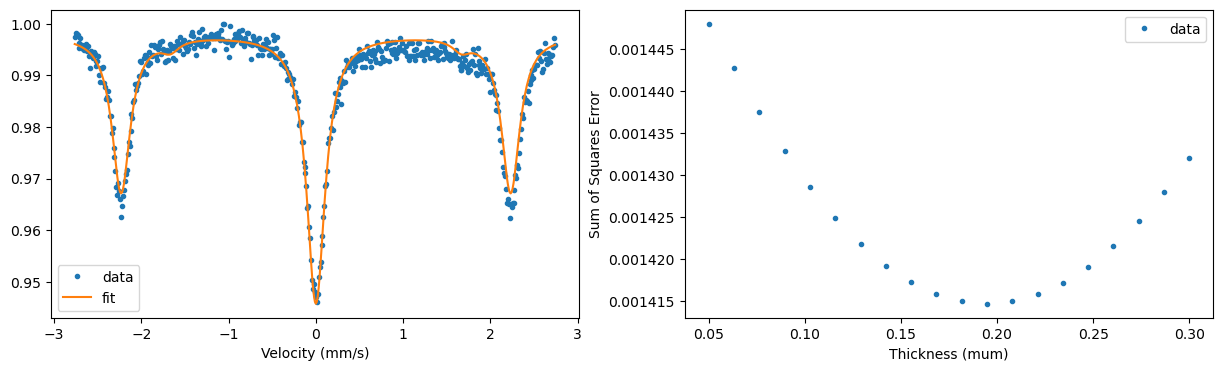

In [20]:
data_alphaFe  = read_ironanalytics_data(directory, "A00137", offset = -3, plot = False)
data_dep10 = read_ironanalytics_data(directory, "A00152", offset = -3, plot = False)
data_dep9 = read_ironanalytics_data(directory, "A00142", offset = -3, plot = False)

data = data_dep9



#SOURCE
source = CobaltFe ()
source.Gamma_ev = 6.9e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.96
absorber.update_params()

#DATA
xdata = data.velocity_list
ydata = data.data_folded/max(data.data_folded)

t_grid = np.linspace(50e-9, 300e-9, 20)
x_model = np.linspace(-30, 30, 1000)

params, sse, x_calibrated, y_model, y_fit = optimize_thickness(xdata, ydata, t_grid,  absorber, source,x_model, fast=True)



print(
    f"t:\t {params['t']*1e6:.2f} mum, \n"
    f"A:\t {params['A']:.3f}, \n"
    f"B:\t {params['B']:.3f}, \n"
    f"x0:\t {params['x0']:.3f} mm/s, \n"
    f"s:\t {params['s']:.3f}"
)


fig, ax = plt.subplots(1,2, figsize=(15,4))
ax[0].plot(x_calibrated, ydata, ".", label="data")
ax[0].plot(x_calibrated, y_fit, "-", label="fit")
ax[0].set_xlabel("Velocity (mm/s)")   
ax[0].legend()

ax[1].plot(t_grid*1e6, sse, ".", label="data")
ax[1].set_xlabel("Thickness (mum)")
ax[1].set_ylabel("Sum of Squares Error")
ax[1].legend()

t:	 0.25 mum, 
A:	 0.343, 
B:	 0.660, 
C:	 -0.001, 
x0:	 -0.003 mm/s, 
s:	 1.382


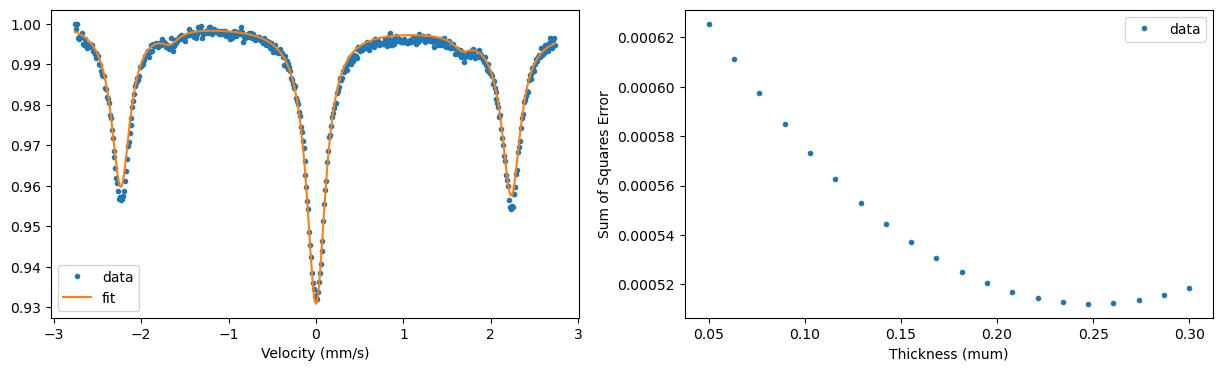

In [5]:
data_alphaFe  = read_ironanalytics_data(directory, "A00137", offset = -3, plot = False)
data_dep10 = read_ironanalytics_data(directory, "A00152", offset = -3, plot = False)
data_dep9 = read_ironanalytics_data(directory, "A00142", offset = -3, plot = False)
data_dep8 = read_ironanalytics_data(directory, "A00141", offset = -3, plot = False)

data = data_dep8



#SOURCE
source = CobaltFe ()
source.Gamma_ev = 6.9e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.96
absorber.update_params()

#DATA
xdata = data.velocity_list
ydata = data.data_folded/max(data.data_folded)

t_grid = np.linspace(50e-9, 300e-9, 20)
x_model = np.linspace(-30, 30, 1000)

params, sse, x_calibrated, y_model, y_fit = optimize_thickness(xdata, ydata, t_grid,  absorber, source,x_model, fast=True)



print(
    f"t:\t {params['t']*1e6:.2f} mum, \n"
    f"A:\t {params['A']:.3f}, \n"
    f"B:\t {params['B']:.3f}, \n"
    f"C:\t {params['C']:.3f}, \n"
    f"x0:\t {params['x0']:.3f} mm/s, \n"
    f"s:\t {params['s']:.3f}"
)


fig, ax = plt.subplots(1,2, figsize=(15,4))
ax[0].plot(x_calibrated, ydata, ".", label="data")
ax[0].plot(x_calibrated, y_fit, "-", label="fit")
ax[0].set_xlabel("Velocity (mm/s)")   
ax[0].legend()

ax[1].plot(t_grid*1e6, sse, ".", label="data")
ax[1].set_xlabel("Thickness (mum)")
ax[1].set_ylabel("Sum of Squares Error")
ax[1].legend()

t:	 30.00 mum, 
A:	 1.212, 
B:	 0.730, 
x0:	 -0.150 mm/s, 
s:	 1.261


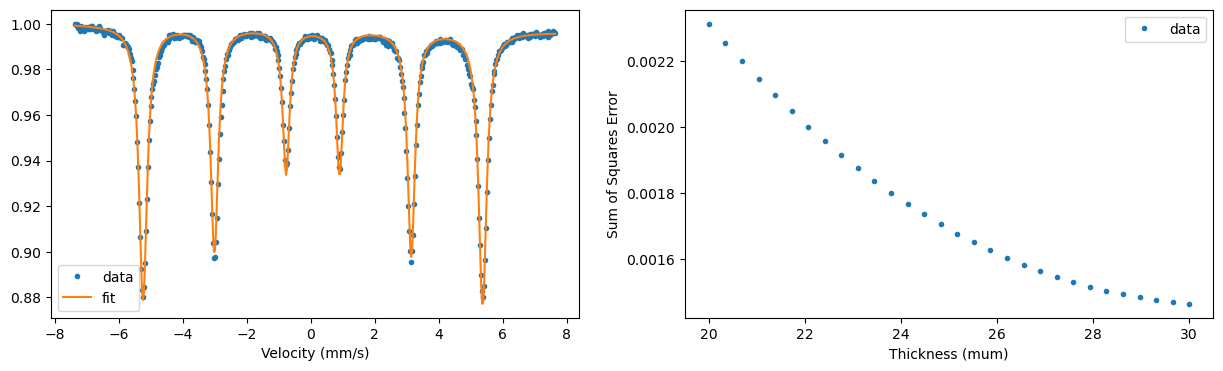

In [130]:
data_alphaFe  = read_ironanalytics_data(directory, "A00166", offset = -3, plot = False)
data_dep10 = read_ironanalytics_data(directory, "A00141", offset = -3, plot = False)

data = data_alphaFe




#SOURCE
source = CobaltRhodium ()
source.Gamma_ev = 6.73e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.0212
absorber.update_params()

#DATA
xdata = data.velocity_list
ydata = data.data_folded/max(data.data_folded)

t_grid = np.linspace(20e-6, 30e-6, 30)
x_model = np.linspace(-30, 30, 1000)

vrange = 8
idx1 = np.argmin(np.abs(xdata+vrange))
idx2 = np.argmin(np.abs(xdata-vrange))

params, sse, x_calibrated, y_model, y_fit = optimize_thickness(xdata[idx1:idx2], ydata[idx1:idx2], t_grid,  absorber, source, x_model, fast=True)



print(
    f"t:\t {params['t']*1e6:.2f} mum, \n"
    f"A:\t {params['A']:.3f}, \n"
    f"B:\t {params['B']:.3f}, \n"
    f"x0:\t {params['x0']:.3f} mm/s, \n"
    f"s:\t {params['s']:.3f}"
)


fig, ax = plt.subplots(1,2, figsize=(15,4))
ax[0].plot(x_calibrated, ydata[idx1:idx2], ".", label="data")
ax[0].plot(x_calibrated, y_fit, "-", label="fit")
ax[0].set_xlabel("Velocity (mm/s)")   
ax[0].legend()

ax[1].plot(t_grid*1e6, sse, ".", label="data")
ax[1].set_xlabel("Thickness (mum)")
ax[1].set_ylabel("Sum of Squares Error")
ax[1].legend()

t:	 25.26 mum, 
A:	 0.719, 
B:	 0.790, 
x0:	 -0.151 mm/s, 
s:	 1.260


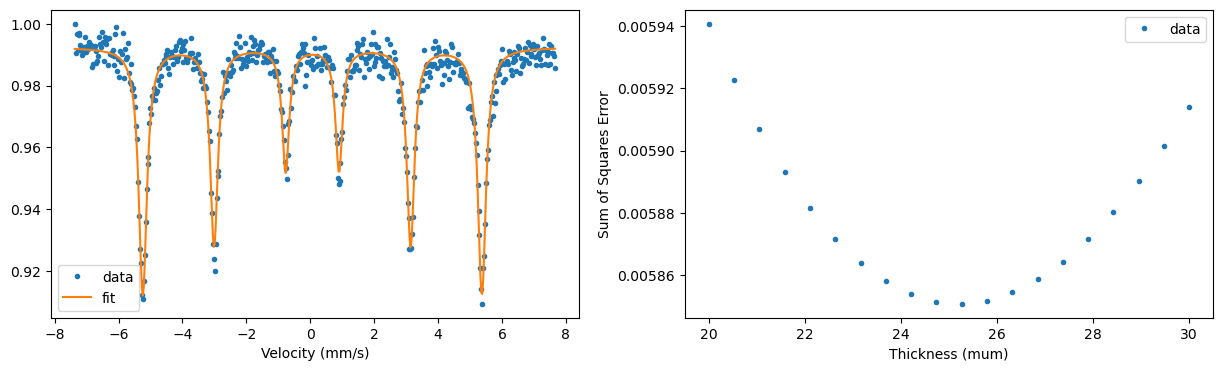

In [39]:
data_alphaFe  = read_ironanalytics_data(directory, "A00165", offset = -3, plot = False)
data_dep10 = read_ironanalytics_data(directory, "A00152", offset = -3, plot = False)

data = data_alphaFe




#SOURCE
source = CobaltRhodium ()
source.Gamma_ev = 7.4e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.0212
absorber.update_params()

#DATA
xdata = data.velocity_list
ydata = data.data_folded/max(data.data_folded)

t_grid = np.linspace(20e-6, 30e-6, 20)
x_model = np.linspace(-30, 30, 1000)

params, sse, x_calibrated, y_model, y_fit = optimize_thickness(xdata, ydata, t_grid,  absorber, source,x_model, fast=True)



print(
    f"t:\t {params['t']*1e6:.2f} mum, \n"
    f"A:\t {params['A']:.3f}, \n"
    f"B:\t {params['B']:.3f}, \n"
    f"x0:\t {params['x0']:.3f} mm/s, \n"
    f"s:\t {params['s']:.3f}"
)


fig, ax = plt.subplots(1,2, figsize=(15,4))
ax[0].plot(x_calibrated, ydata, ".", label="data")
ax[0].plot(x_calibrated, y_fit, "-", label="fit")
ax[0].set_xlabel("Velocity (mm/s)")   
ax[0].legend()

ax[1].plot(t_grid*1e6, sse, ".", label="data")
ax[1].set_xlabel("Thickness (mum)")
ax[1].set_ylabel("Sum of Squares Error")
ax[1].legend()

t:	 0.59 mum, 
A:	 0.491, 
B:	 0.521, 
x0:	 -0.151 mm/s, 
s:	 1.245


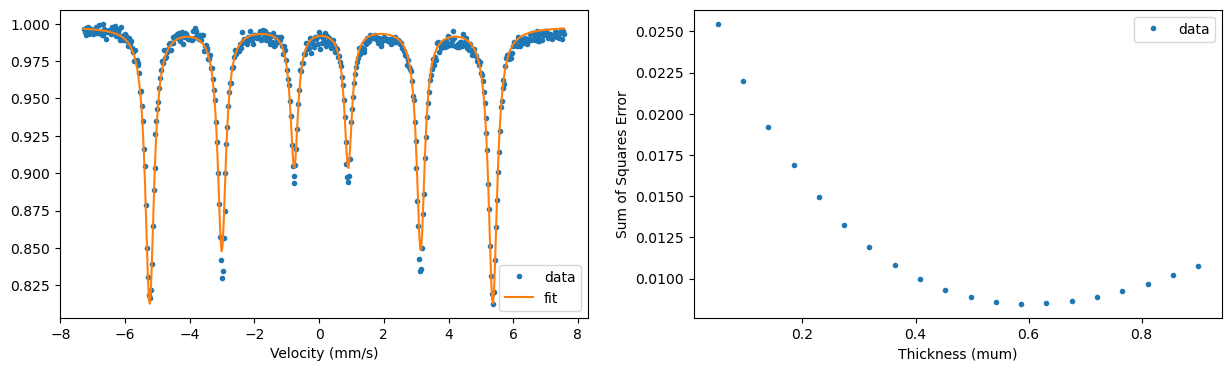

In [32]:
data_alphaFe  = read_ironanalytics_data(directory, "A00166", offset = -3, plot = False)
data_dep10 = read_ironanalytics_data(directory, "A00152", offset = -3, plot = False)

data = data_dep10




#SOURCE
source = CobaltRhodium ()
source.Gamma_ev = 8.1e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.96
absorber.update_params()

#DATA
xdata = data.velocity_list
ydata = data.data_folded/max(data.data_folded)

t_grid = np.linspace(50e-9, 900e-9, 20)
x_model = np.linspace(-30, 30, 1000)

params, sse, x_calibrated, y_model, y_fit = optimize_thickness(xdata, ydata, t_grid,  absorber, source,x_model, fast=True)



print(
    f"t:\t {params['t']*1e6:.2f} mum, \n"
    f"A:\t {params['A']:.3f}, \n"
    f"B:\t {params['B']:.3f}, \n"
    f"x0:\t {params['x0']:.3f} mm/s, \n"
    f"s:\t {params['s']:.3f}"
)


fig, ax = plt.subplots(1,2, figsize=(15,4))
ax[0].plot(x_calibrated, ydata, ".", label="data")
ax[0].plot(x_calibrated, y_fit, "-", label="fit")
ax[0].set_xlabel("Velocity (mm/s)")   
ax[0].legend()

ax[1].plot(t_grid*1e6, sse, ".", label="data")
ax[1].set_xlabel("Thickness (mum)")
ax[1].set_ylabel("Sum of Squares Error")
ax[1].legend()

t:	 0.54 mum, 
A:	 0.461, 
B:	 0.549, 
x0:	 -0.150 mm/s, 
s:	 1.259


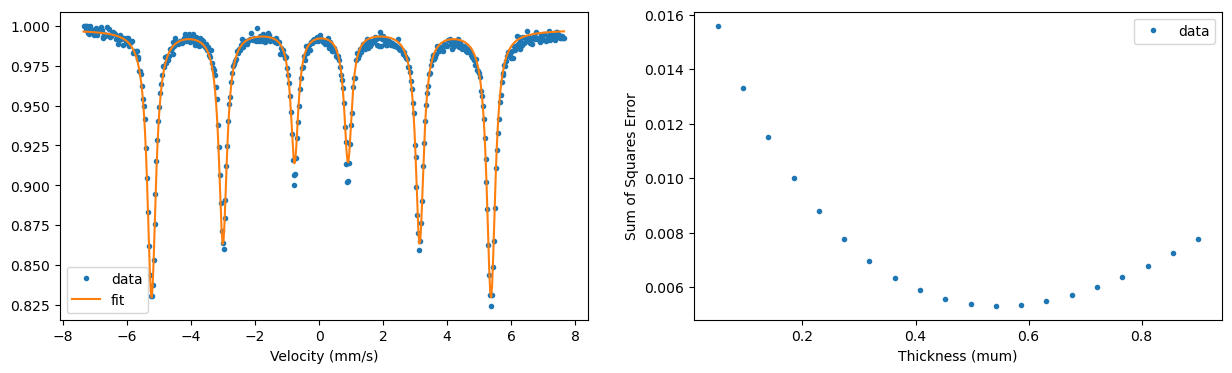

In [40]:
data_alphaFe  = read_ironanalytics_data(directory, "A00166", offset = -3, plot = False)
data_dep10 = read_ironanalytics_data(directory, "A00152", offset = -3, plot = False)
data_dep11 = read_ironanalytics_data(directory, "A00168", offset = -3, plot = False)
data = data_dep11




#SOURCE
source = CobaltRhodium ()
source.Gamma_ev = 8.1e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.96
absorber.update_params()

#DATA
xdata = data.velocity_list
ydata = data.data_folded/max(data.data_folded)

t_grid = np.linspace(50e-9, 900e-9, 20)
x_model = np.linspace(-30, 30, 1000)

params, sse, x_calibrated, y_model, y_fit = optimize_thickness(xdata, ydata, t_grid,  absorber, source, x_model, fast=True)



print(
    f"t:\t {params['t']*1e6:.2f} mum, \n"
    f"A:\t {params['A']:.3f}, \n"
    f"B:\t {params['B']:.3f}, \n"
    f"x0:\t {params['x0']:.3f} mm/s, \n"
    f"s:\t {params['s']:.3f}"
)


fig, ax = plt.subplots(1,2, figsize=(15,4)) 
ax[0].plot(x_calibrated, ydata, ".", label="data")
ax[0].plot(x_calibrated, y_fit, "-", label="fit")
ax[0].set_xlabel("Velocity (mm/s)")   
ax[0].legend()

ax[1].plot(t_grid*1e6, sse, ".", label="data")
ax[1].set_xlabel("Thickness (mum)")
ax[1].set_ylabel("Sum of Squares Error")
ax[1].legend()

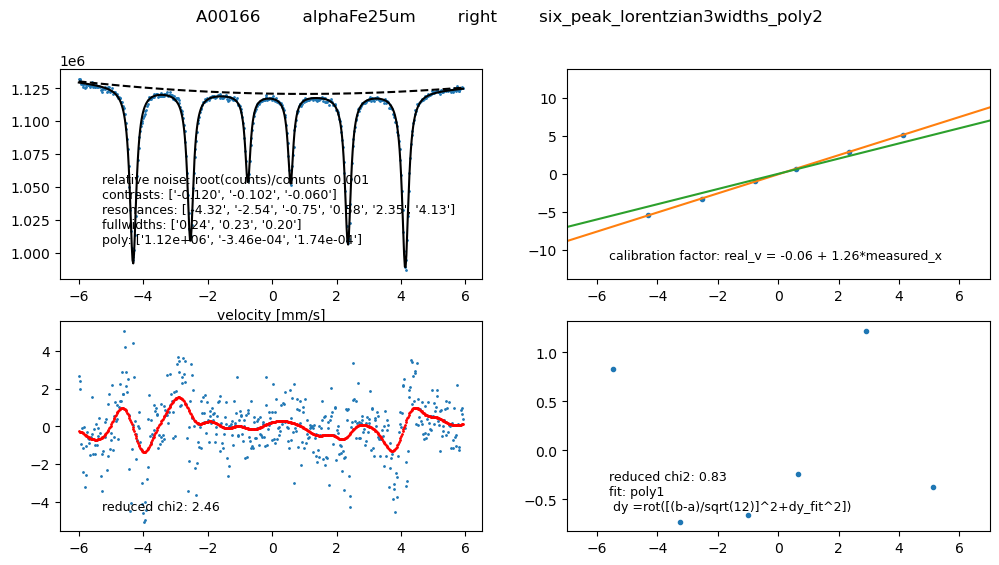

In [45]:
from mossbauer_analysis.ironanalytics_load import read_ironanalytics_data, print_ironanalytics_metadata 
import mossbauer_analysis.utils as u
from mossbauer_analysis.ironanalytics_analyze import fit_and_calibrate
from mossbauer_analysis.fit_functions import linear, poly2,poly5, single_peak_lorentzian_poly1, single_peak_lorentzian_poly2, six_peak_lorentzian3widths_poly2, six_peak_lorentzian_poly1,six_peak_lorentzian_poly2, six_peak_lorentzian_poly5



fit_guess = {
            'contrasts': [-1e2, -1e2, -1e2],
            'resonances': [-4.32,-2.55,-0.78,0.55,2.31,4.09],
            'fullwidths': [0.3, 0.3, 0.3],
            'poly': [3e5, 1e2, 1e1],  
            }


params = {  'directory':  "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/",
            'id': 'A00166',
            'offset': -3,
            'side': 'right',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian3widths_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
        
        } 

params = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True)

widths_exp  = params['fullwidths_calibrated']
cont_exp  = params['contrasts']

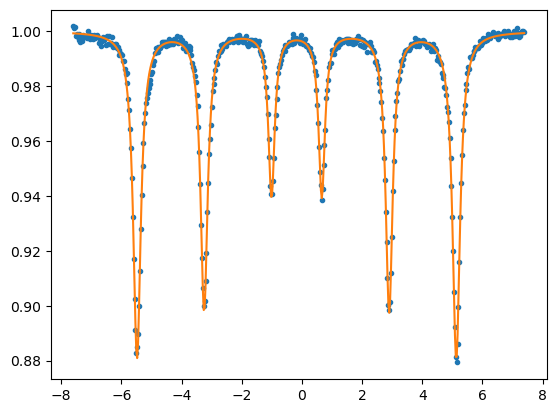

In [46]:
p = params['contrasts'] + params['calibration_resonances'] + params['fullwidths_calibrated'] + params['poly']
x_calibrated = params['x_calibrated']
fullwidth = params['fullwidths_calibrated']
y_norm = params['y_norm']
fitfuntion = params['fitfunction']
x = params['x']


plt.plot(x_calibrated, y_norm, ".", label="data")
plt.plot(x_calibrated, fitfuntion(p, x_calibrated)/poly2(params['poly'],x_calibrated), "-", label="fit")

In [123]:
print_ironanalytics_metadata(directory)


ID: A00001,	 v_max: 10,	  det: 70,	 10,	 1213,	 2503,	 Description: 
ID: A00002,	 v_max: 30,	  det: 70,	 10,	 2040,	 2080,	 Description: 
ID: A00003,	 v_max: 30,	  det: 70,	 10,	 2040,	 2080,	 Description: 
ID: A00004,	 v_max: 10,	  det: 70,	 10,	 2040,	 2080,	 Description: 
ID: A00005,	 v_max: 10,	  det: 70,	 10,	 2040,	 2080,	 Description: 
ID: A00006,	 v_max: 10,	  det: 70,	 10,	 2040,	 2080,	 Description: 
ID: A00007,	 v_max: 10,	  det: 70,	 10,	 1551,	 3278,	 Description: test
ID: A00008,	 v_max: 10,	  det: 70,	 10,	 1551,	 3278,	 Description: test VD PID adjusted
ID: A00009,	 v_max: 10,	  det: 70,	 10,	 1551,	 3278,	 Description: alpha_iron
ID: A00010,	 v_max: 10,	  det: 70,	 10,	 1551,	 3278,	 Description: alpha_iron
ID: A00010_meta,	 v_max: ,	  det: ,	 ,	 ,	 ,	 Description: 
ID: A00011,	 v_max: 10,	  det: 70,	 10,	 1551,	 3278,	 Description: alpha_iron+B4C
ID: A00012,	 v_max: 10,	  det: 70,	 10,	 1551,	 3278,	 Description: Be disk
ID: A00013,	 v_max: 10,	  det: 70,	 10,	 1551,	

widths (mm/s):  [0.3022082488781117, 0.2799951246050446, 0.243389793442914]


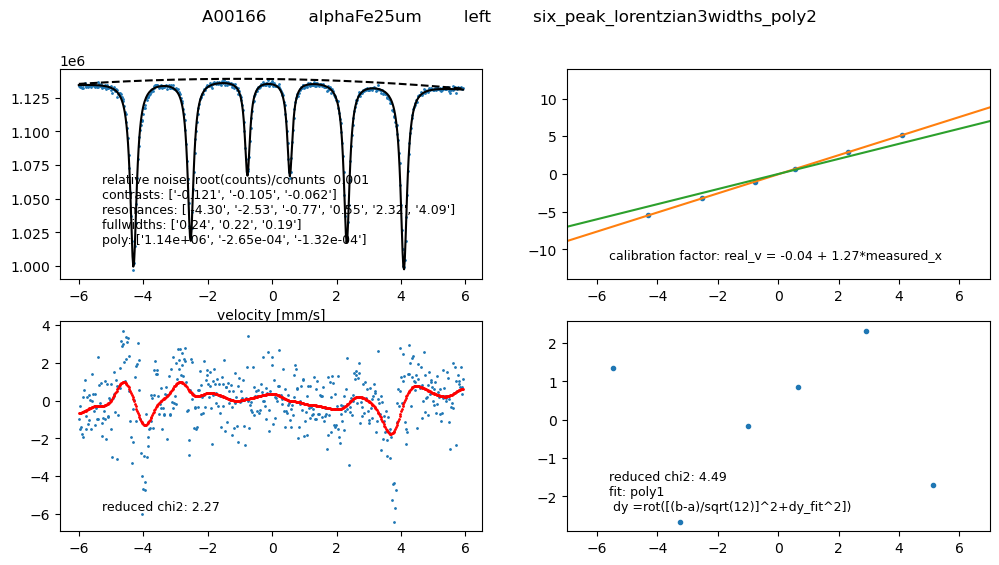

In [142]:

fit_guess = {
            'contrasts': [-1e2, -1e2, -1e2],
            'resonances': [-4.32,-2.55,-0.78,0.55,2.31,4.09],
            'fullwidths': [0.3, 0.3, 0.3],
            'poly': [3e5, 1e2, 1e1],  
            }


params = {  'directory':  "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/",
            'id': 'A00166',
            'offset': -3,
            'side': 'left',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian3widths_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
        
        } 

params = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True)

widths_exp  = params['fullwidths_calibrated']
cont_exp  = params['contrasts']
print("widths (mm/s): ", widths_exp)


widths (mm/s):  [0.2971773911702287, 0.27378969728917774, 0.23802850215000987]


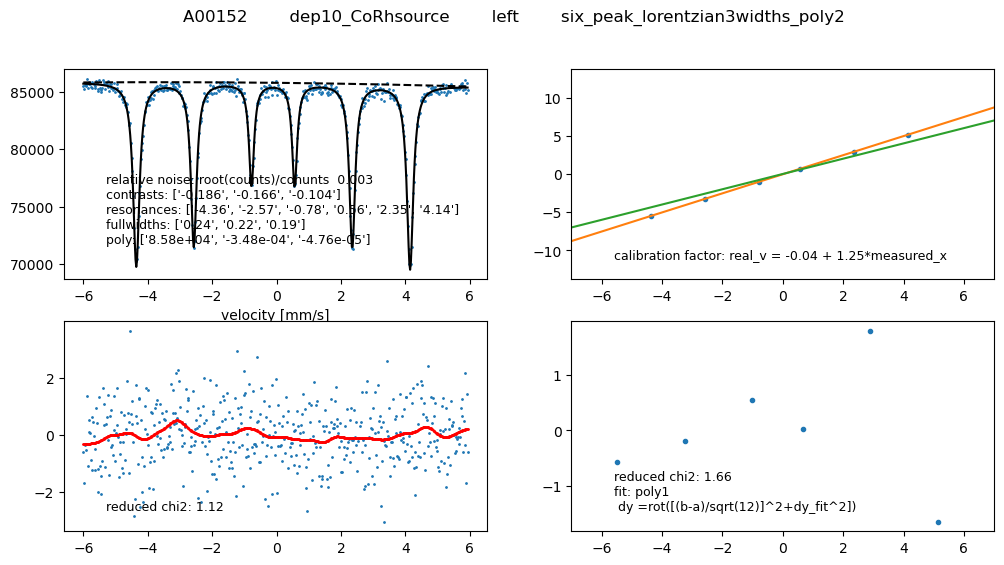

In [144]:


fit_guess = {
            'contrasts': [-1e2, -1e2, -1e2],
            'resonances': [-4.32,-2.55,-0.78,0.55,2.31,4.09],
            'fullwidths': [0.3, 0.3, 0.3],
            'poly': [3e5, 1e2, 1e1],  
            }


params = {  'directory':  "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/",
            'id': 'A00152',
            'offset': -3,
            'side': 'left',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian3widths_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
        
        } 

params = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True)

widths_exp2  = params['fullwidths_calibrated']
cont_exp2  = params['contrasts']
print("widths (mm/s): ", widths_exp2)


widths (mm/s):  [0.30288787323118715, 0.2731940208005574, 0.2479597583667098]


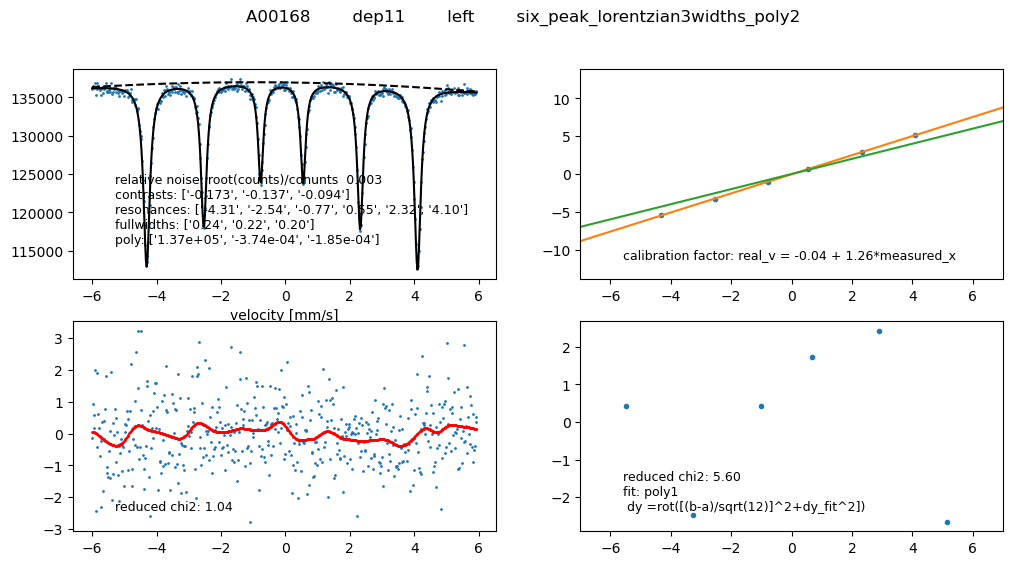

In [143]:
fit_guess = {
            'contrasts': [-1e2, -1e2, -1e2],
            'resonances': [-4.32,-2.55,-0.78,0.55,2.31,4.09],
            'fullwidths': [0.2, 0.2, 0.2],
            'poly': [3e5, 1e2, 1e1],  
            }


params = {  'directory':  "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/",
            'id': 'A00168',
            'offset': -3,
            'side': 'left',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian3widths_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
        
        } 

params = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True)

widths_exp3  = params['fullwidths_calibrated']
cont_exp3  = params['contrasts']
print("widths (mm/s): ", widths_exp3)

In [40]:
from mossbauer_analysis.ironanalytics_load import read_ironanalytics_data, print_ironanalytics_metadata 
import mossbauer_analysis.utils as u
from mossbauer_analysis.ironanalytics_analyze import fit_and_calibrate
from mossbauer_analysis.mossbauer_theory import CobaltRhodium, CobaltFe, KFeCy, alphaFe, Mossbauer, _lorentzian_s, mms_to_ev, ev_to_mms, epsilon
from mossbauer_analysis.mossbauer_fit_model import optimize_linewidth_s, optimize_thickness, fit_gamma_and_thickness
from mossbauer_analysis.fit_functions import six_peak_lorentzian3widths_poly2, six_peak_lorentzian_poly2 

import numpy as np
import matplotlib.pyplot as plt

directory = "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/"
data_alphaFe = read_ironanalytics_data(directory, "A00156", offset = -3, plot = False)
data_dep10 = read_ironanalytics_data(directory, "A00152", offset = -3, plot = False)
data_dep102mms = read_ironanalytics_data(directory, "A00153", offset = -3, plot = False)
data_dep9 = read_ironanalytics_data(directory, "A00142", offset = -3, plot = False)
data_alphaFeFesource = read_ironanalytics_data(directory, "A00137", offset = -3, plot = False)
data_dep8 = read_ironanalytics_data(directory, "A00141", offset = -3, plot = False)

#data_alphaFe = read_ironanalytics_data(directory, "A00164", offset = -3, plot = False)

9.360147450407023

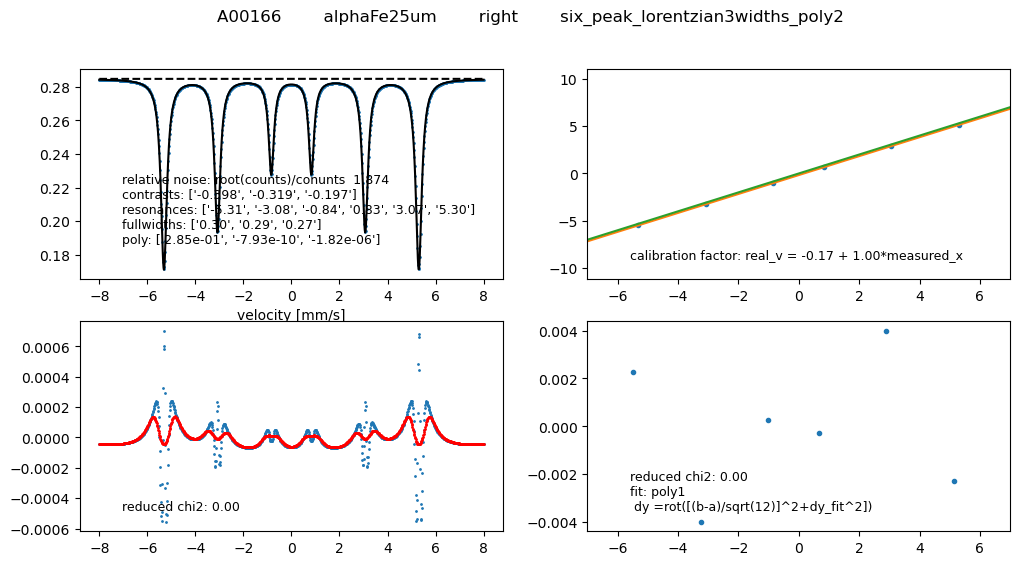

In [41]:
#SOURCE
source = CobaltRhodium ()
source.Eres = [-0.18]
source.Gamma_ev = 7.3e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.0212
absorber.update_params()

moss = Mossbauer(source, absorber)

x = np.linspace(-8, 8, 1000)
y = moss.total_transmission_rate(x)



fit_guess = {
            'contrasts': [-1e1, -1e1, -1e1],
            'resonances':  [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
            'fullwidths':  [0.3, 0.3, 0.3],
            'poly': [3e0, 0, 0],  
            }


params = {  'directory':  "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/",
            'id': 'A00166',
            'offset': -3,
            'side': 'right',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian3widths_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
}


params = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True, data = [x, y])

widths_mod  = params['fullwidths_calibrated']
cont_mod  = params['contrasts']
absorber.thickness_normalized

In [80]:
def thickness_broadening(effective_thickness):
    thin = 1 + 0.135*effective_thickness
    thick = 1.01 + 0.145*effective_thickness - 0.0025*effective_thickness**2
    broadening = np.where(effective_thickness <= 4., thin, thick)
    broadening = np.minimum(thin, thick)
    return broadening

def relative_broadening(effective_thickness, relative_intensities = [3/12,2/12,1/12]):
    effective_thickness = np.array(effective_thickness)
    relative_intensities = np.array(relative_intensities)
    broadening_val = thickness_broadening(relative_intensities[:, np.newaxis]*effective_thickness[np.newaxis, :])
    return broadening_val

def relative_contrasts(effective_thickness, relative_intensities = [3/12,2/12,1/12]):
    effective_thickness = np.array(effective_thickness)
    relative_intensities = np.array(relative_intensities)
    epsilon_val = epsilon(relative_intensities[:, np.newaxis] * effective_thickness[np.newaxis, :])
    return epsilon_val


t = np.linspace(0.1, 40, 100)

g0, g1, g2 = relative_broadening(t)
c0,c1,c2 = relative_contrasts(t)



In [136]:
#SOURCE
source = CobaltRhodium ()
source.Eres =[-0.17] #from pipcorn
source.Gamma_ev =6.17e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.0212
absorber.update_params()

moss = Mossbauer(source, absorber)

x = np.linspace(-8, 8, 1000)
y = moss.total_transmission_rate(x)



fit_guess = {
            'contrasts': [-1e1, -1e1, -1e1],
            'resonances':  [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
            'fullwidths':  [0.25, 0.25, 0.25],
            'poly': [3e0, 0, 0],  
            }


params = {  'directory':  "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/",
            'id': 'A00166',
            'offset': -3,
            'side': 'right',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian3widths_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
}


widths_mod_list = []
cont_mod_list = []

th_m = np.linspace(0.1, 100, 30)*1e-6
th_norm =[]
for th in th_m:
    absorber.thickness_m = th
    absorber.update_params()
    moss = Mossbauer(source, absorber)
    x = np.linspace(-8, 8, 1000)
    y = moss.total_transmission_rate(x)


    params = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = False, data = [x, y])

    th_norm.append(absorber.thickness_normalized) 
    widths_mod_list.append(params['fullwidths_calibrated'])
    cont_mod_list.append(params['contrasts'])


dGamma 0.03375 0.12854166666666667 0.09479166666666666 [0.3022082488781117, 0.2799951246050446, 0.243389793442914]


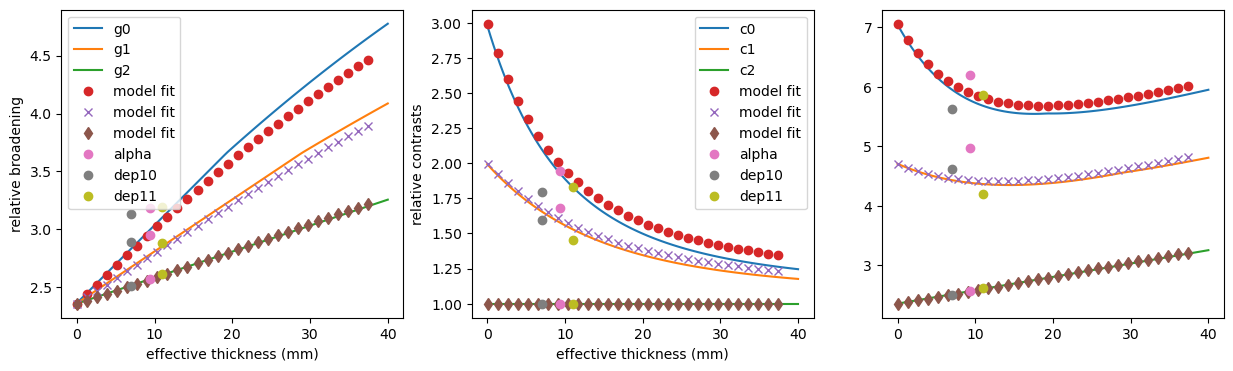

In [149]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)

t =np.linspace(0,40,100)

th_exp = 3*[9.36]
th_exp2 = 3*[7.]
th_exp3 = 3*[11.]

dGamma = source.Gamma_mms-absorber.Gamma_mms

natural_linewidth = absorber.Gamma_mms
print("dGamma", dGamma, source.Gamma_mms, absorber.Gamma_mms, widths_exp)

plt.plot(t, 2*g0+dGamma/natural_linewidth, label="g0")
plt.plot(t, 2*g1+dGamma/natural_linewidth, label="g1")
plt.plot(t, 2*g2+dGamma/natural_linewidth, label="g2")

plt.plot(th_norm,  (np.array(widths_mod_list).T[0])/natural_linewidth, "o", label="model fit")
plt.plot(th_norm,  (np.array(widths_mod_list).T[1])/natural_linewidth , "x", label="model fit")
plt.plot(th_norm,  (np.array(widths_mod_list).T[2])/natural_linewidth , "d", label="model fit")


plt.plot(th_exp, np.array(widths_exp)/natural_linewidth, "o", label="alpha")
plt.plot(th_exp2, np.array(widths_exp2)/natural_linewidth, "o", label="dep10")
plt.plot(th_exp3,np.array(widths_exp3)/natural_linewidth, "o", label="dep11")

plt.xlabel("effective thickness (mm)")
plt.ylabel("relative broadening")
plt.legend()

plt.subplot(1,3,2)
plt.plot(t, c0/c2, label="c0")
plt.plot(t, c1/c2, label="c1")
plt.plot(t, c2/c2, label="c2")


plt.plot(th_norm,  np.array(cont_mod_list).T[0]/np.array(cont_mod_list).T[2], "o", label="model fit")
plt.plot(th_norm,  np.array(cont_mod_list).T[1]/np.array(cont_mod_list).T[2], "x", label="model fit")
plt.plot(th_norm,  np.array(cont_mod_list).T[2]/np.array(cont_mod_list).T[2], "d", label="model fit")

plt.plot(th_exp, np.array(cont_exp)/cont_exp[2], "o", label="alpha")
plt.plot(th_exp2, np.array(cont_exp2)/cont_exp2[2], "o", label="dep10")
plt.plot(th_exp3,np.array(cont_exp3)/cont_exp3[2], "o", label="dep11")

plt.xlabel("effective thickness (mm)")
plt.ylabel("relative contrasts")
plt.legend()


plt.subplot(1,3,3)

#dGamma = 0.06

plt.plot(t, (2*g0+dGamma/natural_linewidth)*c0/c2, label="g0")
plt.plot(t, (2*g1+dGamma/natural_linewidth)*c1/c2, label="g1")
plt.plot(t, (2*g2+dGamma/natural_linewidth)*c2/c2, label="g2")


plt.plot(th_norm,  np.array(widths_mod_list).T[0]/natural_linewidth*np.array(cont_mod_list).T[0]/np.array(cont_mod_list).T[2], "o", label="model fit")
plt.plot(th_norm,  np.array(widths_mod_list).T[1]/natural_linewidth*np.array(cont_mod_list).T[1]/np.array(cont_mod_list).T[2], "x", label="model fit")
plt.plot(th_norm,  np.array(widths_mod_list).T[2]/natural_linewidth*np.array(cont_mod_list).T[2]/np.array(cont_mod_list).T[2], "d", label="model fit")

plt.plot(th_exp, np.array(cont_exp)/cont_exp[2]*np.array(widths_exp)/natural_linewidth, "o", label="alpha")
plt.plot(th_exp2, np.array(cont_exp2)/cont_exp2[2]*np.array(widths_exp2)/natural_linewidth, "o", label="dep10")
plt.plot(th_exp3, np.array(cont_exp3)/cont_exp3[2]*np.array(widths_exp3)/natural_linewidth, "o", label="dep11")




In [118]:
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.0212
absorber.update_params()
source_width_mms = natural_linewidth + (widths_exp[2] - 2*thickness_broadening(absorber.thickness_normalized*1/12)*natural_linewidth)
mms_to_ev(14.4e3,source_width_mms)


6.174464990024454e-09

In [ ]:
np.array(cont_exp3)/cont_exp3[2], widths_exp3, 

(array([1.83240129, 1.45429854, 1.        ]),
 [0.30288787323118715, 0.2731940208005574, 0.2479597583667098])

## order of analysis:
- 1 calibrate velocity and normalize baseline
- fit linewidth
- derive source linewidth, by comparing with reference absorber (known thickness)
- fit sample model to derive thickness thickness with known source linewidth. 

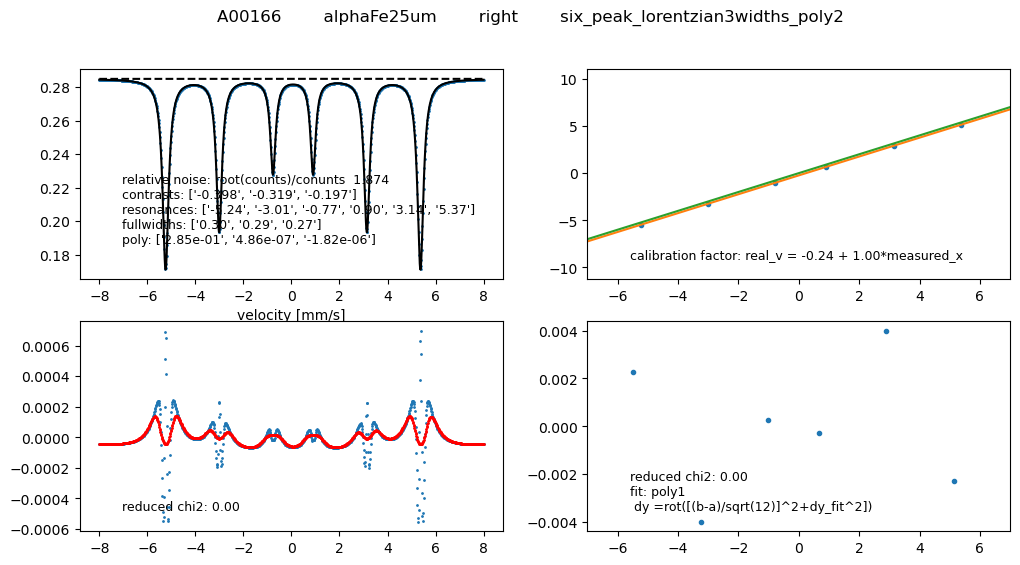

In [1]:
from mossbauer_analysis.ironanalytics_load import read_ironanalytics_data, print_ironanalytics_metadata 
import mossbauer_analysis.utils as u
from mossbauer_analysis.ironanalytics_analyze import fit_and_calibrate
from mossbauer_analysis.mossbauer_theory import CobaltRhodium, CobaltFe, KFeCy, alphaFe, Mossbauer, _lorentzian_s, mms_to_ev, ev_to_mms
from mossbauer_analysis.mossbauer_fit_model import optimize_linewidth_s, optimize_thickness, fit_gamma_and_thickness
from mossbauer_analysis.fit_functions import six_peak_lorentzian3widths_poly2, six_peak_lorentzian_poly2 

import numpy as np
import matplotlib.pyplot as plt

directory = "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/"
data_alphaFe = read_ironanalytics_data(directory, "A00156", offset = -3, plot = False)
data_dep10 = read_ironanalytics_data(directory, "A00152", offset = -3, plot = False)
data_dep102mms = read_ironanalytics_data(directory, "A00153", offset = -3, plot = False)
data_dep9 = read_ironanalytics_data(directory, "A00142", offset = -3, plot = False)
data_alphaFeFesource = read_ironanalytics_data(directory, "A00137", offset = -3, plot = False)
data_dep8 = read_ironanalytics_data(directory, "A00141", offset = -3, plot = False)

#data_alphaFe = read_ironanalytics_data(directory, "A00164", offset = -3, plot = False)


source = CobaltRhodium ()
source.Gamma_ev = 7.3e-9
source.update_params()


#ABSORBER
absorber = alphaFe()
absorber.thickness_m = 25e-6
absorber.abundance = 0.0212
absorber.update_params()

moss = Mossbauer(source, absorber)

x = np.linspace(-8, 8, 1000)
y = moss.total_transmission_rate(x)



fit_guess = {
            'contrasts': [-1e1, -1e1, -1e1],
            'resonances':  [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
            'fullwidths': [0.3, 0.3, 0.3],
            'poly': [3e0, 0, 0],  
            }


params = {  'directory':  "C:/Users/magrini/Documents/programming/mossbauer_analysis/data/SpectraA/",
            'id': 'A00166',
            'offset': -3,
            'side': 'right',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian3widths_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
}


params = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True, data = [x, y])


In [179]:
np.mean( [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13])

-0.17499999999999996

In [154]:
gamma = widths_exp3
gamma_nat = 0.097
b_lin = 0.135

dgamma02 = gamma[0]-gamma[2]
dgamma12 = gamma[1]-gamma[2]

F0 = dgamma02/(2*gamma_nat*b_lin)
F1 = dgamma12/(2*gamma_nat*b_lin)


G0 = dgamma02/(dgamma12-dgamma02)
G1 = dgamma12/(dgamma12-dgamma02)

A0 = G0/(1-G0)
B0 = F0/(1-G0)

A1 = G1/(1-G0)
B1 = F1/(1-G0)

t1= (A1*B0+B0)/(1-A1*A0)
t2 = (A0*B1+B1)/(1-A1*A0)
 
print("t1: ", t1, "t2: ", t2)


t1:  0.6404493921776544 t2:  0.14711289544237371
